In [3]:
%pip install mne pyedflib tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
almazov_data = '../dataset/edf/'
almazov_descr = '../dataset/descriptions/'
file_path = almazov_data + '111.edf'

In [16]:
# Загрузка
raw = mne.io.read_raw_edf(file_path, preload=True)

# Выбираем каналы
# resp_channels = ['RESP Breath-0', 'RESP Breath-1', 'RESP CHEST Thora', 'RESP ABDOMEN Abd']
resp_channels = ['RESP Breath-0', 'RESP Breath-1', 'PPG', 'SAO2 SpO2']
existing_resp = [ch for ch in resp_channels if ch in raw.ch_names]
print("Найденные каналы:", existing_resp)

# Получаем данные в виде numpy массивов (каналы x время)
sfreq = raw.info['sfreq']
data = raw.get_data(picks=existing_resp)   # форма (n_channels, n_samples)
times = raw.times

Extracting EDF parameters from ../dataset/edf/111.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 46459493  =      0.000 ... 46505.999 secs...


/var/folders/vb/ln0by8yd5g188n3xwgtwx5dr0000gn/T/ipykernel_53303/3214694620.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'RESP Breath'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Найденные каналы: ['RESP Breath-0', 'RESP Breath-1', 'PPG', 'SAO2 SpO2']


In [5]:
raw.ch_names

['EEG F3-A2',
 'EEG C3-A2',
 'EEG O1-A2',
 'EEG F4-A1',
 'EEG C4-A1',
 'EEG O2-A1',
 'EMG PZ-A1_CHIN_L',
 'EMG_CHIN_R[E1]',
 'EOG EOGl FZ-A2_E',
 'EOG EOGr FPZ-A2_',
 'EMG LMl OZ-A2_LM',
 'EMG LMr CZ-A2_LM',
 'SOUND Snore',
 'ECG  ECG',
 'RESP Breath-0',
 'RESP CHEST Thora',
 'RESP ABDOMEN Abd',
 'SAO2 SpO2',
 'PPG',
 'RESP Breath-1']

Канал |	Вероятное значение
RESP Breath-0 |	Один из каналов дыхательного потока (чаще всего назальный термистор или канюля давления)
RESP Breath-1 |	Второй канал потока (иногда дополнительный датчик, или резервный)
RESP CHEST Thora |	Плетизмограф грудной клетки (торакальные усилия)
RESP ABDOMEN Abd |	Плетизмограф брюшной стенки (абдоминальные усилия)
PPG | Фотоплетизмография
SpO2 | Насыщение крови кислородом

In [6]:
print(raw)

<RawEDF | 111.edf, 20 x 46459494 (46506.0 s), ~6.92 GiB, data loaded>


In [8]:
# Применяем фильтр к каждому каналу
def bandpass_filter(data, lowcut=0.1, highcut=0.8, fs=sfreq, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

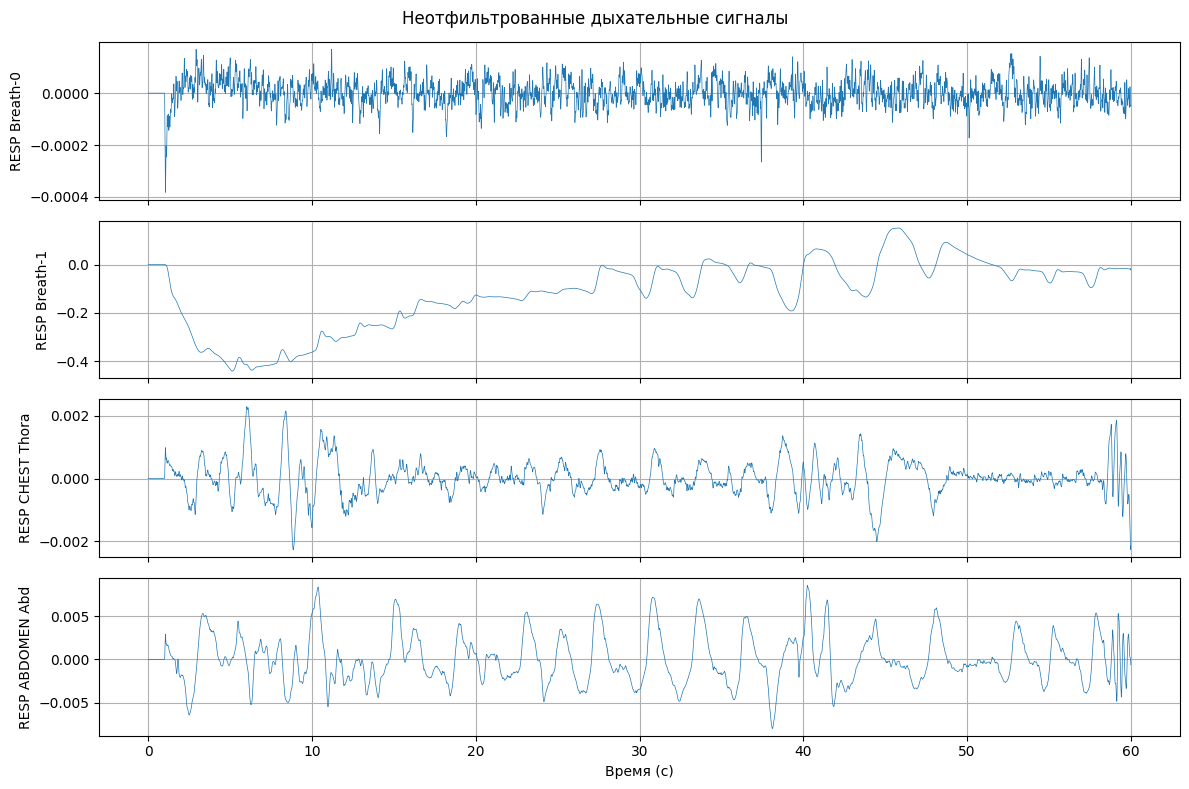

In [12]:
data_no_filt = np.array([(data[i]) for i in range(len(existing_resp))])

# Визуализация первых 60 секунд
duration_plot = 60
n_samples_plot = int(duration_plot * sfreq)
t_plot = times[:n_samples_plot]

fig, axes = plt.subplots(len(existing_resp), 1, figsize=(12, 8), sharex=True)
for i, ch in enumerate(existing_resp):
    axes[i].plot(t_plot, data_no_filt[i, :n_samples_plot], linewidth=0.5)
    axes[i].set_ylabel(ch)
    axes[i].grid(True)
axes[-1].set_xlabel('Время (с)')
plt.suptitle('Неотфильтрованные дыхательные сигналы')
plt.tight_layout()
plt.show()

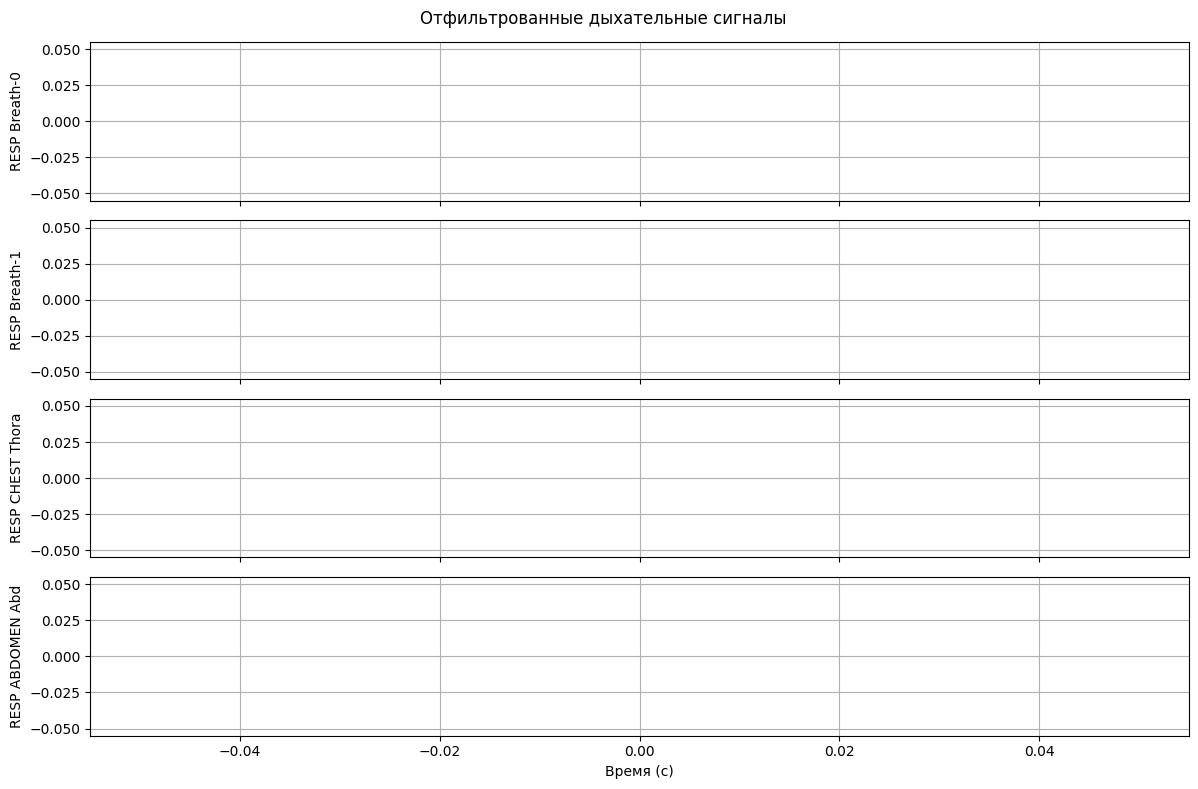

In [13]:
data_filt = np.array([bandpass_filter(data[i]) for i in range(len(existing_resp))])

# Визуализация первых 60 секунд
duration_plot = 60
n_samples_plot = int(duration_plot * sfreq)
t_plot = times[:n_samples_plot]

fig, axes = plt.subplots(len(existing_resp), 1, figsize=(12, 8), sharex=True)
for i, ch in enumerate(existing_resp):
    axes[i].plot(t_plot, data_filt[i, :n_samples_plot], linewidth=0.5)
    axes[i].set_ylabel(ch)
    axes[i].grid(True)
axes[-1].set_xlabel('Время (с)')
plt.suptitle('Отфильтрованные дыхательные сигналы')
plt.tight_layout()
plt.show()

In [14]:
# Спектральный анализ для первого канала
ch_idx = 0
# f, Pxx = signal.welch(data_filt[ch_idx], fs=sfreq, nperseg=int(sfreq*30))  # nperseg должен быть int
f, Pxx = signal.welch(data_no_filt[ch_idx], fs=sfreq, nperseg=int(sfreq*30))  # nperseg должен быть int

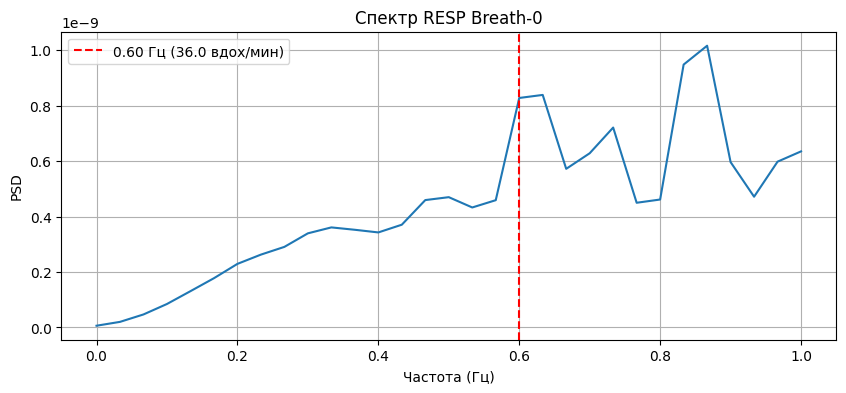

In [15]:
# Строим график
mask = (f >= 0) & (f <= 1)
plt.figure(figsize=(10,4))
plt.plot(f[mask], Pxx[mask])
plt.xlabel('Частота (Гц)')
plt.ylabel('PSD')
plt.title(f'Спектр {existing_resp[ch_idx]}')
# поиск пика
peak_mask = (f >= 0.1) & (f <= 0.6)
if np.any(peak_mask):
    peak_freq = f[peak_mask][np.argmax(Pxx[peak_mask])]
    plt.axvline(peak_freq, color='r', linestyle='--', label=f'{peak_freq:.2f} Гц ({peak_freq*60:.1f} вдох/мин)')
    plt.legend()
plt.grid(True)
plt.show()